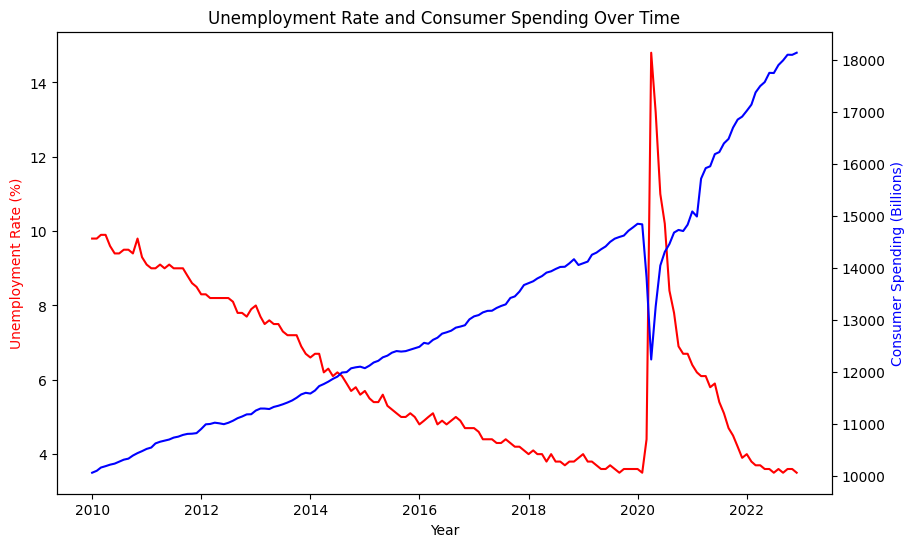

unemployment_rate ADF Statistic: -2.673, p-value: 0.079
consumer_spending ADF Statistic: 1.341, p-value: 0.997
unemployment_rate_diff ADF Statistic: -9.910, p-value: 0.000
consumer_spending_diff ADF Statistic: -10.746, p-value: 0.000

Granger Causality Tests:
Does unemployment rate Granger-cause consumer spending?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=88.8940 , p=0.0000  , df_denom=151, df_num=1
ssr based chi2 test:   chi2=90.6601 , p=0.0000  , df=1
likelihood ratio test: chi2=71.2893 , p=0.0000  , df=1
parameter F test:         F=88.8940 , p=0.0000  , df_denom=151, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=33.0524 , p=0.0000  , df_denom=148, df_num=2
ssr based chi2 test:   chi2=68.3382 , p=0.0000  , df=2
likelihood ratio test: chi2=56.4958 , p=0.0000  , df=2
parameter F test:         F=33.0524 , p=0.0000  , df_denom=148, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=22.873

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as web
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

# Fetch data from FRED
start_date, end_date = '2010-01-01', '2022-12-31'
df = pd.concat([
    web.DataReader('UNRATE', 'fred', start_date, end_date),
    web.DataReader('PCE', 'fred', start_date, end_date)
], axis=1).rename(columns={'UNRATE': 'unemployment_rate', 'PCE': 'consumer_spending'})

# Reset index to use date column explicitly
df = df.reset_index().rename(columns={'DATE': 'date'})

# Save DataFrame to CSV
df.to_csv('unemployment_spending.csv', index=False)

# Plot data with proper years on x-axis
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_title('Unemployment Rate and Consumer Spending Over Time')
ax1.set_xlabel('Year')
ax1.set_ylabel('Unemployment Rate (%)', color='red')
ax1.plot(df['date'], df['unemployment_rate'], color='red')

ax2 = ax1.twinx()
ax2.set_ylabel('Consumer Spending (Billions)', color='blue')
ax2.plot(df['date'], df['consumer_spending'], color='blue')

plt.savefig('unemployment_consumer_spending.png')
plt.show()

# Stationarity tests (ADF)
for col in ['unemployment_rate', 'consumer_spending']:
    adf_result = adfuller(df[col])
    print(f'{col} ADF Statistic: {adf_result[0]:.3f}, p-value: {adf_result[1]:.3f}')

# Differencing to achieve stationarity
df['unemployment_rate_diff'] = df['unemployment_rate'].diff()
df['consumer_spending_diff'] = df['consumer_spending'].diff()

# ADF Test after differencing
for col in ['unemployment_rate_diff', 'consumer_spending_diff']:
    adf_result = adfuller(df[col].dropna())
    print(f'{col} ADF Statistic: {adf_result[0]:.3f}, p-value: {adf_result[1]:.3f}')

# Granger causality tests
print('\nGranger Causality Tests:')
print('Does unemployment rate Granger-cause consumer spending?')
granger_test_ur_cs = grangercausalitytests(df[['consumer_spending_diff', 'unemployment_rate_diff']].dropna(), maxlag=4)

print('\nDoes consumer spending Granger-cause unemployment rate?')
granger_test_cs_ur = grangercausalitytests(df[['unemployment_rate_diff', 'consumer_spending_diff']].dropna(), maxlag=4)

[*********************100%***********************]  1 of 1 completed


Selected Copula: FRANK


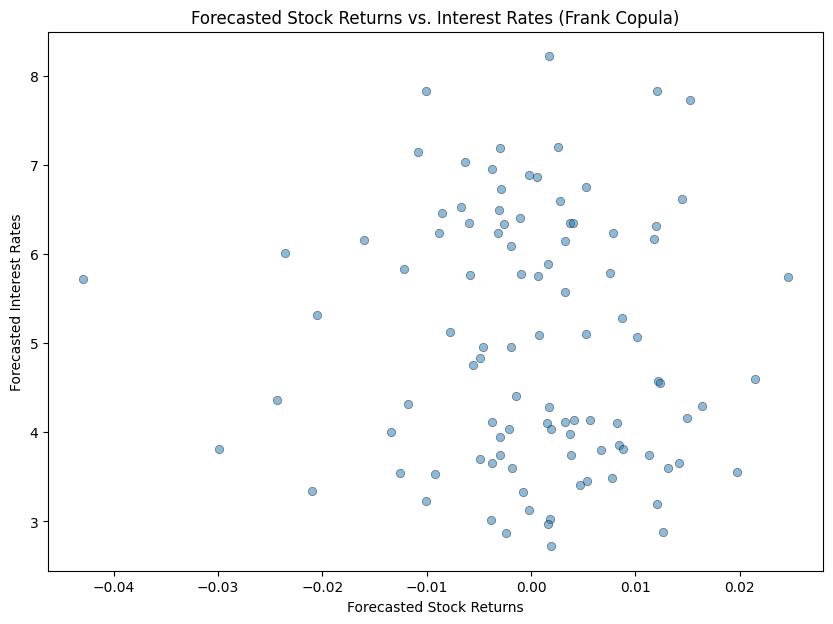

In [21]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt
from copulas.bivariate import Bivariate

# Set seed for reproducibility
np.random.seed(42)

# Retrieve 30-year Mortgage interest rates from FRED
interest_rate_data = web.DataReader('MORTGAGE30US', 'fred', start='2000-01-01', end='2025-01-01')
interest_rate_data.dropna(inplace=True)

# Retrieve stock data (S&P 500 index) from Yahoo Finance
stock_data = yf.download("^GSPC", start="2000-01-01", end="2025-01-01")
stock_returns = stock_data['Close'].pct_change().dropna()

# Align the two datasets on common dates
data = pd.concat([stock_returns, interest_rate_data], axis=1, join='inner').dropna()
data.columns = ['Stock Returns', 'Interest Rates']

# Transform to uniform scale
time_steps = len(data)
u = stats.rankdata(data['Stock Returns']) / (time_steps + 1)
v = stats.rankdata(data['Interest Rates']) / (time_steps + 1)

# Automatically select the best copula
uv = np.column_stack((u, v))
best_copula = Bivariate.select_copula(uv)
print(f"Selected Copula: {best_copula.copula_type.name}")

# Fit selected copula to capture dependency
best_copula.fit(uv)

# Simulate future dependencies (forecasting)
samples = best_copula.sample(100)
u_future = samples[:, 0]
v_future = samples[:, 1]

# Transform forecasts back to original scale
returns_forecast = np.quantile(data['Stock Returns'], u_future)
rates_forecast = np.quantile(data['Interest Rates'], v_future)

# Visualization
plt.figure(figsize=(10, 7))
plt.scatter(returns_forecast, rates_forecast, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.xlabel("Forecasted Stock Returns")
plt.ylabel("Forecasted Interest Rates")
plt.title(f"Forecasted Stock Returns vs. Interest Rates ({best_copula.copula_type.name.capitalize()} Copula)")
plt.grid(False)
plt.savefig("copula_forecast_stock_interest_real_data.png")
plt.show()


Best copula selected: FRANK


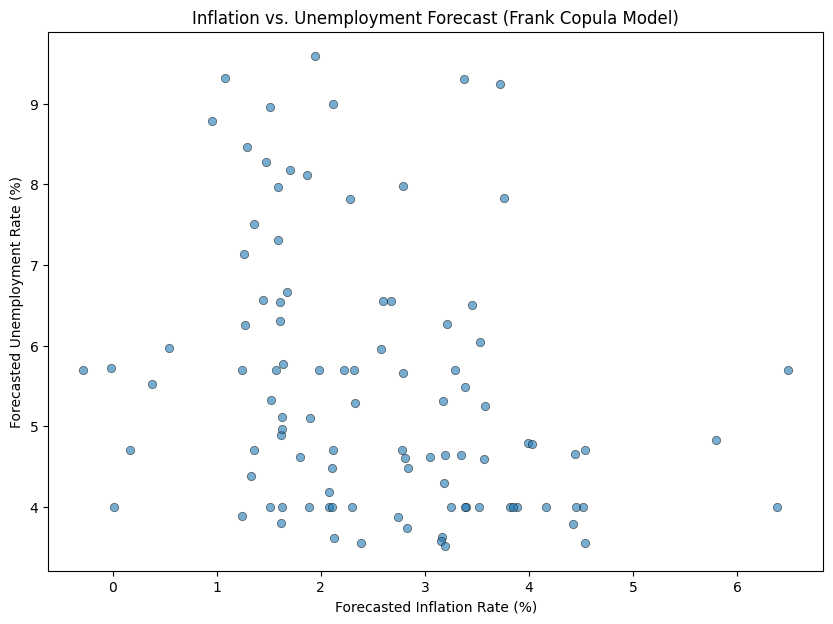

In [22]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import scipy.stats as stats
import matplotlib.pyplot as plt
from copulas.bivariate import Bivariate, CopulaTypes

# Set seed for reproducibility
np.random.seed(42)

# Fetch real macroeconomic data from FRED
inflation = web.DataReader('FPCPITOTLZGUSA', 'fred', start='2000-01-01', end='2025-01-01')
unemployment = web.DataReader('UNRATE', 'fred', start='2000-01-01', end='2025-01-01')

# Clean and align data
data = pd.concat([inflation, unemployment], axis=1, join='inner').dropna()
data.columns = ['Inflation', 'Unemployment']

# Transform data to uniform scale (probabilities)
n = len(data)
u = stats.rankdata(data['Inflation']) / (n + 1)
v = stats.rankdata(data['Unemployment']) / (n + 1)
uv = np.column_stack((u, v))

# Automatically select the best copula
best_copula = Bivariate.select_copula(uv)
print(f"Best copula selected: {best_copula.copula_type.name}")

# Fit the best copula
best_copula.fit(uv)

# Simulate future dependencies
samples = best_copula.sample(100)
u_future = samples[:, 0]
v_future = samples[:, 1]

# Transform simulated dependencies back to original data scale
inflation_forecast = np.quantile(data['Inflation'], u_future)
unemployment_forecast = np.quantile(data['Unemployment'], v_future)

# Visualization of forecasts
plt.figure(figsize=(10, 7))
plt.scatter(inflation_forecast, unemployment_forecast, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.xlabel("Forecasted Inflation Rate (%)")
plt.ylabel("Forecasted Unemployment Rate (%)")
plt.title(f"Inflation vs. Unemployment Forecast ({best_copula.copula_type.name.capitalize()} Copula Model)")
plt.grid(False)
plt.savefig(f"{best_copula.copula_type.name.lower()}_copula_forecast_inflation_unemployment.png")
plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1995 entries, 0 to 1994
Data columns (total 84 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          1995 non-null   int64  
 1   state         1995 non-null   int64  
 2   name          1995 non-null   object 
 3   chrstprot     1995 non-null   int64  
 4   chrstcat      1995 non-null   int64  
 5   chrstorth     1995 non-null   int64  
 6   chrstang      1995 non-null   int64  
 7   chrstothr     1995 non-null   int64  
 8   chrstgen      1995 non-null   int64  
 9   judorth       1995 non-null   int64  
 10  jdcons        1995 non-null   int64  
 11  judref        1993 non-null   float64
 12  judothr       1995 non-null   int64  
 13  judgen        1995 non-null   int64  
 14  islmsun       1995 non-null   int64  
 15  islmshi       1995 non-null   int64  
 16  islmibd       1995 non-null   int64  
 17  islmnat       1995 non-null   int64  
 18  islmalw       1995 non-null 

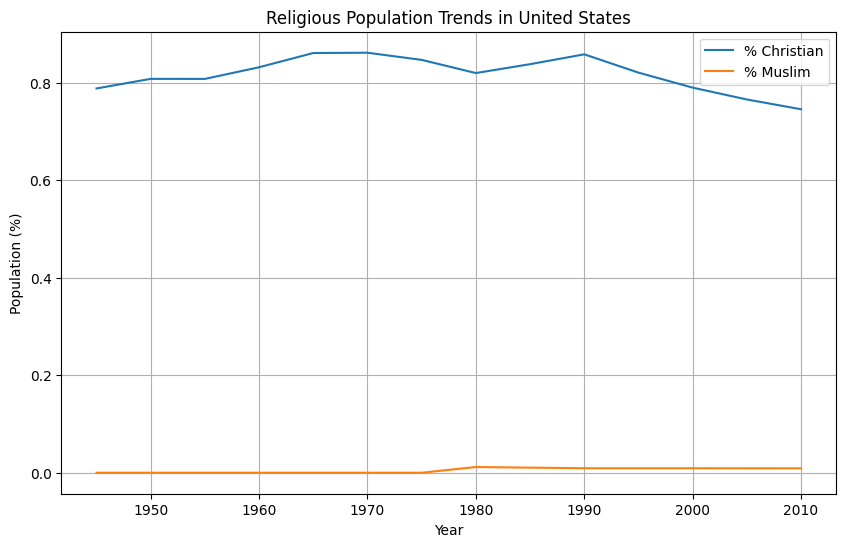

ADF Test for Christian Population:
Test Statistic: 1.2796
P-Value: 0.9965
Christian Population has a unit root (non-stationary).

ADF Test for Muslim Population:
Test Statistic: -1.2056
P-Value: 0.6712
Muslim Population has a unit root (non-stationary).

Engle-Granger Cointegration Test:
Test Statistic: -0.0000
P-Value: 0.9859
Critical Values: [-4.93727846 -3.84651047 -3.38679083]
The two series are not cointegrated.
                            OLS Regression Results                            
Dep. Variable:            chrstgenpct   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.224
Date:                Sat, 22 Mar 2025   Prob (F-statistic):              0.290
Time:                        21:32:46   Log-Likelihood:                 27.959
No. Observations:                  14   AIC:                            -51.92
Df Residuals:             

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


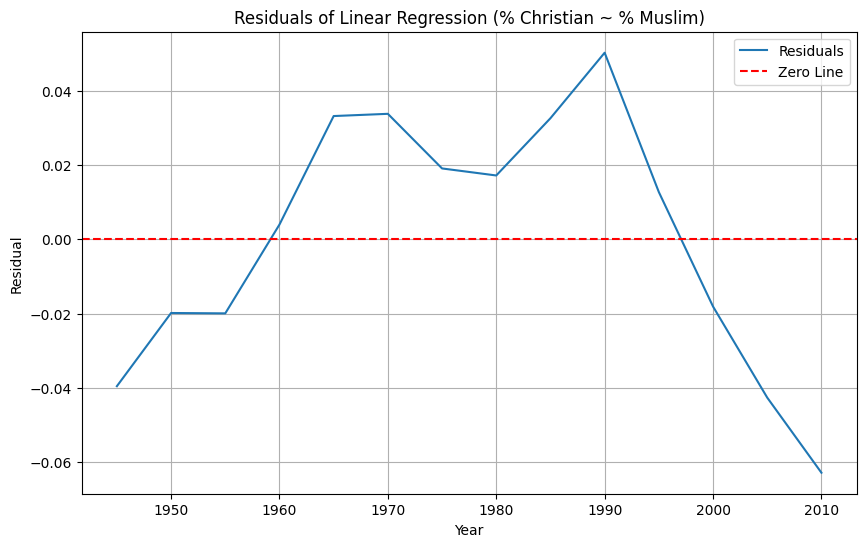

ADF Test for Regression Residuals:
Test Statistic: 1.3361
P-Value: 0.9968
Regression Residuals has a unit root (non-stationary).



In [24]:

import pandas as pd

# Load your dataset
file_path = 'WRP_national.csv'
wrp_data = pd.read_csv(file_path)

# Display basic information and first few rows
print(wrp_data.info())
print(wrp_data.head())

# Example filtering by country and selecting relevant columns
name = 'USA'  # or another country present in your dataset
country_data = wrp_data[wrp_data['name'] == name][['year', 'chrstgenpct', 'islmgenpct']].dropna()

# Ensure sorted by year
country_data = country_data.sort_values('year')

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(country_data['year'], country_data['chrstgenpct'], label='% Christian')
plt.plot(country_data['year'], country_data['islmgenpct'], label='% Muslim')
plt.title(f"Religious Population Trends in {country}")
plt.xlabel('Year')
plt.ylabel('Population (%)')
plt.legend()
plt.grid()
plt.show()

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"P-Value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"{name} has a unit root (non-stationary).\n")
    else:
        print(f"{name} is stationary.\n")

adf_test(country_data['chrstgenpct'], 'Christian Population')
adf_test(country_data['islmgenpct'], 'Muslim Population')

from statsmodels.tsa.stattools import coint

coint_stat, p_value, critical_values = coint(country_data['chrstgenpct'], country_data['islmgenpct'])

print("Engle-Granger Cointegration Test:")
print(f"Test Statistic: {coint_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Critical Values: {critical_values}")
if p_value < 0.05:
    print("The two series are cointegrated.")
else:
    print("The two series are not cointegrated.")


import statsmodels.api as sm

X = sm.add_constant(country_data['islmgenpct'])
y = country_data['chrstgenpct']

model = sm.OLS(y, X).fit()
print(model.summary())

# Plot residuals to visually inspect stationarity
plt.figure(figsize=(10,6))
plt.plot(country_data['year'], model.resid, label="Residuals")
plt.axhline(0, linestyle='--', color='red', label='Zero Line')
plt.title("Residuals of Linear Regression (% Christian ~ % Muslim)")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.legend()
plt.grid()
plt.show()

# Residual stationarity check with ADF test
adf_test(model.resid, 'Regression Residuals')
